In [0]:
# ============================================================
#  INTERNATIONAL DEBT ANALYSIS
#  Source: World Bank International Debt Statistics
#  Dataset: 124 Countries | 25 Indicators | 2,357 Records
#  Tools: R (ggplot2, dplyr, tidyr, car, corrplot, ggrepel)
# ============================================================

# ── 0. INSTALL & LOAD PACKAGES ──────────────────────────────

# Run install lines once, then comment them out
install.packages(c("ggplot2","dplyr","tidyr","scales","ggthemes",
                   "RColorBrewer","corrplot","reshape2","ggrepel",
                   "gridExtra","car","BSDA","patchwork","viridis"))

library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)
library(RColorBrewer)
library(corrplot)
library(reshape2)
library(ggrepel)
library(gridExtra)
library(car)
library(patchwork)
library(viridis)

* installing *binary* package ‘dplyr’ ...
* DONE (dplyr)
* installing *binary* package ‘RColorBrewer’ ...
* DONE (RColorBrewer)
* installing *binary* package ‘corrplot’ ...
* DONE (corrplot)
* installing *binary* package ‘reshape2’ ...
* DONE (reshape2)
* installing *binary* package ‘gridExtra’ ...
* DONE (gridExtra)
* installing *binary* package ‘BSDA’ ...
* DONE (BSDA)
* installing *binary* package ‘tidyr’ ...
* DONE (tidyr)
* installing *binary* package ‘scales’ ...
* DONE (scales)
* installing *binary* package ‘ggplot2’ ...
* DONE (ggplot2)
* installing *binary* package ‘car’ ...
* DONE (car)
* installing *binary* package ‘ggthemes’ ...
* DONE (ggthemes)
* installing *binary* package ‘ggrepel’ ...
* DONE (ggrepel)
* installing *binary* package ‘patchwork’ ...
* DONE (patchwork)
* installing *binary* package ‘viridis’ ...
* DONE (viridis)
Installing packages into ‘/local_disk0/.ephemeral_nfs/envs/rEnv-ac2fa3a6-bae7-4abd-9839-7f8810e8f904’
(as ‘lib’ is unspecified)
trying URL 'https:

In [0]:
PAL <- c(navy  = "#1B2A4A",
         mid   = "#64748B",
         slate = "#475569",
         teal  = "#14B8A6",
         red   = "#E63946",
         gold  = "#F59E0B")

THEME <- theme_minimal(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 16, colour = PAL["navy"]),
    plot.subtitle    = element_text(size = 11, colour = PAL["mid"], margin = margin(b = 10)),
    plot.caption     = element_text(size = 9, colour = PAL["mid"], hjust = 0),
    axis.title       = element_text(size = 11, colour = PAL["slate"]),
    axis.text        = element_text(size = 10, colour = PAL["slate"]),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(colour = "#E2E8F0"),
    plot.background  = element_rect(fill = "white", colour = NA),
    panel.background = element_rect(fill = "white", colour = NA),
    legend.position  = "bottom",
    legend.title     = element_text(size = 10, face = "bold"),
    strip.text       = element_text(face = "bold", colour = PAL["navy"])
  )

# Apply as default theme
theme_set(THEME)

In [0]:
# SECTION 1 — LOAD & INSPECT DATA
# ============================================================

df <- read.csv("/Workspace/Users/shahneel364@gmail.com/Drafts/international_debt.csv", stringsAsFactors = FALSE)

# --- Quick look ---
cat("=== DATASET OVERVIEW ===\n")
cat("Rows:", nrow(df), "\n")
cat("Columns:", ncol(df), "\n")
cat("Column names:", paste(names(df), collapse = ", "), "\n\n")

glimpse(df)

# --- Missing values ---
cat("\n=== MISSING VALUES ===\n")
print(colSums(is.na(df)))

# --- Unique counts ---
cat("\nUnique countries:", n_distinct(df$country_name), "\n")
cat("Unique indicators:", n_distinct(df$indicator_name), "\n")

=== DATASET OVERVIEW ===
Rows: 2357 
Columns: 5 
Column names: country_name, country_code, indicator_name, indicator_code, debt 

Rows: 2,357
Columns: 5
$ country_name   <chr> "Afghanistan", "Afghanistan", "Afghanistan", "Afghanist…
$ country_code   <chr> "AFG", "AFG", "AFG", "AFG", "AFG", "AFG", "AFG", "AFG",…
$ indicator_name <chr> "Disbursements on external debt, long-term (DIS, curren…
$ indicator_code <chr> "DT.DIS.DLXF.CD", "DT.INT.DLXF.CD", "DT.AMT.BLAT.CD", "…
$ debt           <dbl> 72894454, 53239440, 61739337, 49114729, 39903620, 39107…

=== MISSING VALUES ===
  country_name   country_code indicator_name indicator_code           debt 
             0              0              0              0              0 

Unique countries: 124 
Unique indicators: 25 

In [0]:
# ============================================================
# SECTION 2 — FEATURE ENGINEERING
# ============================================================

# Extract indicator category from indicator_code
# e.g. DT.DIS.DLXF.CD -> DIS, DT.AMT.BLAT.CD -> AMT
df$cat <- sapply(strsplit(df$indicator_code, "\\."), function(x) x[2])
cat("Indicator categories:", paste(sort(unique(df$cat)), collapse = ", "), "\n")

# Aggregate debt by country
country_debt <- df %>%
  group_by(country_name) %>%
  summarise(
    total_debt = sum(debt) / 1e9,
    n_indicators = n_distinct(indicator_name),
    mean_debt = mean(debt) / 1e9,
    .groups = "drop"
  ) %>%
  arrange(desc(total_debt))

cat("\nTop 5 debtor countries ($ Billions):\n")
print(head(country_debt, 5))

Indicator categories: AMT, DIS, INT 

Top 5 debtor countries ($ Billions):
# A tibble: 5 × 4
  country_name                                 total_debt n_indicators mean_debt
  <chr>                                             <dbl>        <int>     <dbl>
1 China                                              286.           24     11.9 
2 Brazil                                             281.           24     11.7 
3 South Asia                                         248.           24     10.3 
4 Least developed countries: UN classification       213.           25      8.52
5 Russian Federation                                 191.           21      9.11

In [0]:
# ============================================================
# SECTION 3 — DATA PREPARATION
# ============================================================

top10 <- country_debt %>% head(10)

country_rank <- country_debt %>%
  mutate(rank = row_number())

# Log-transformed debt for normality-sensitive tests
df$debt_log <- log10(df$debt + 1)

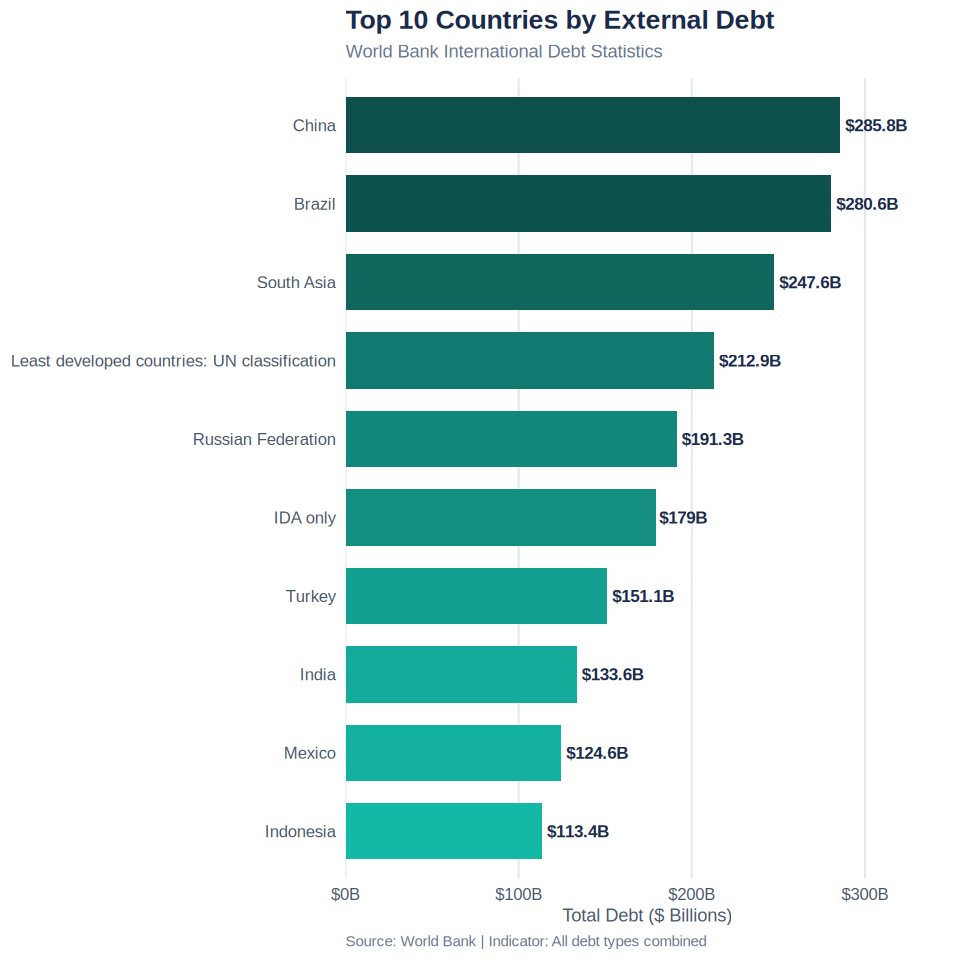

In [0]:

# ============================================================
# SECTION 4 — VISUALISATIONS
# ============================================================

# -----------------------------------------------------------
# GRAPH 1: Horizontal Bar — Top 10 Countries by Total Debt
# -----------------------------------------------------------

p1 <- ggplot(top10,
             aes(x = reorder(country_name, total_debt),
                 y = total_debt,
                 fill = total_debt)) +
  geom_col(width = 0.72, show.legend = FALSE) +
  geom_text(aes(label = paste0("$", round(total_debt, 1), "B")),
            hjust = -0.08, size = 3.6, fontface = "bold",
            colour = PAL["navy"]) +
  coord_flip() +
  scale_fill_gradient(low = "#14B8A6", high = "#0D4F4A") +
  scale_y_continuous(
    labels   = dollar_format(suffix = "B"),
    expand   = expansion(mult = c(0, 0.22))
  ) +
  labs(
    title    = "Top 10 Countries by External Debt",
    subtitle = "World Bank International Debt Statistics",
    x        = NULL,
    y        = "Total Debt ($ Billions)",
    caption  = "Source: World Bank | Indicator: All debt types combined"
  ) +
  theme(panel.grid.major.y = element_blank())

print(p1)
ggsave("graph1_top10_countries.png", p1, width = 10, height = 6, dpi = 150)



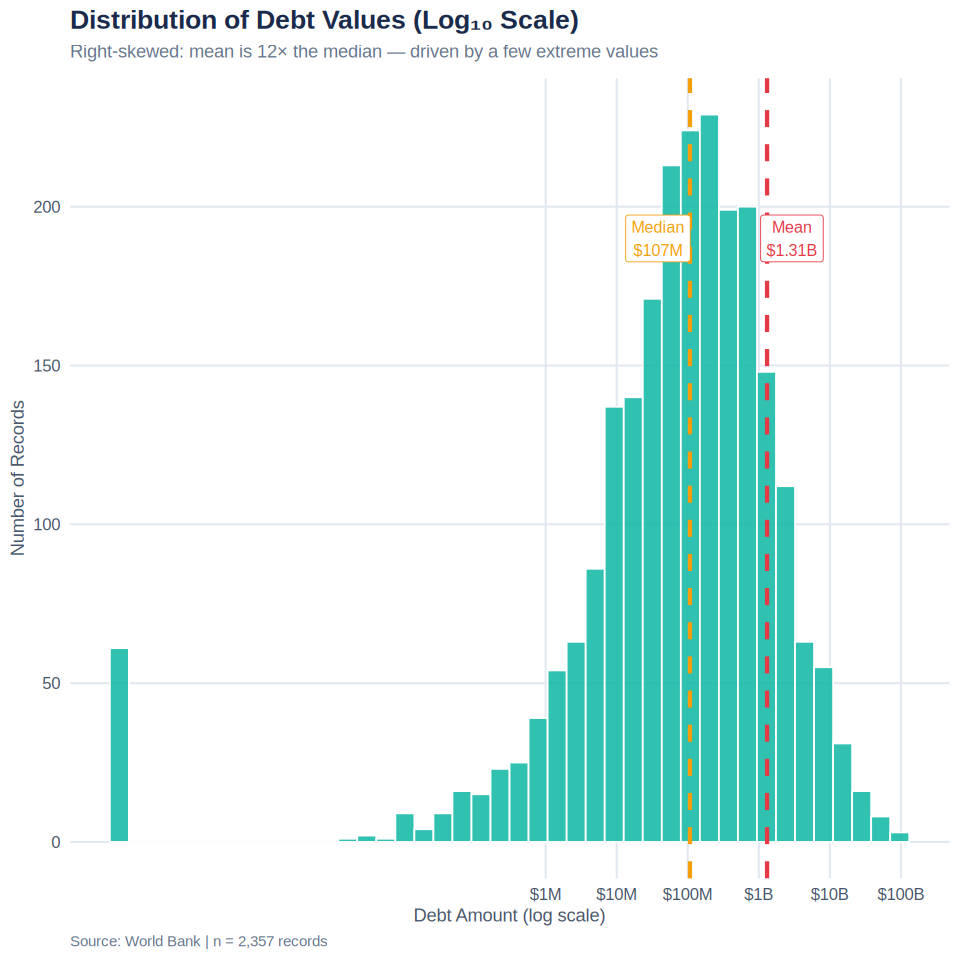

In [0]:

# -----------------------------------------------------------
# GRAPH 2: Histogram — Debt Distribution on Log₁₀ Scale
# -----------------------------------------------------------

mean_log  <- log10(mean(df$debt))
median_log <- log10(median(df$debt))

p2 <- ggplot(df, aes(x = log10(debt + 1))) +
  geom_histogram(bins = 42, fill = PAL["teal"], colour = "white",
                 alpha = 0.88) +
  geom_vline(xintercept = mean_log,
             colour = PAL["red"], linetype = "dashed", linewidth = 1.2) +
  geom_vline(xintercept = median_log,
             colour = PAL["gold"], linetype = "dashed", linewidth = 1.2) +
  annotate("label",
           x = mean_log + 0.35, y = 190,
           label = paste0("Mean\n$", round(mean(df$debt) / 1e9, 2), "B"),
           colour = PAL["red"], fill = "white", size = 3.4,
           label.padding = unit(0.3, "lines")) +
  annotate("label",
           x = median_log - 0.45, y = 190,
           label = paste0("Median\n$", round(median(df$debt) / 1e6, 0), "M"),
           colour = PAL["gold"], fill = "white", size = 3.4,
           label.padding = unit(0.3, "lines")) +
  scale_x_continuous(
    breaks = 6:11,
    labels = c("$1M", "$10M", "$100M", "$1B", "$10B", "$100B")
  ) +
  labs(
    title    = "Distribution of Debt Values (Log\u2081\u2080 Scale)",
    subtitle = "Right-skewed: mean is 12\u00d7 the median \u2014 driven by a few extreme values",
    x        = "Debt Amount (log scale)",
    y        = "Number of Records",
    caption  = "Source: World Bank | n = 2,357 records"
  )

print(p2)
ggsave("graph2_debt_distribution.png", p2, width = 10, height = 6, dpi = 150)


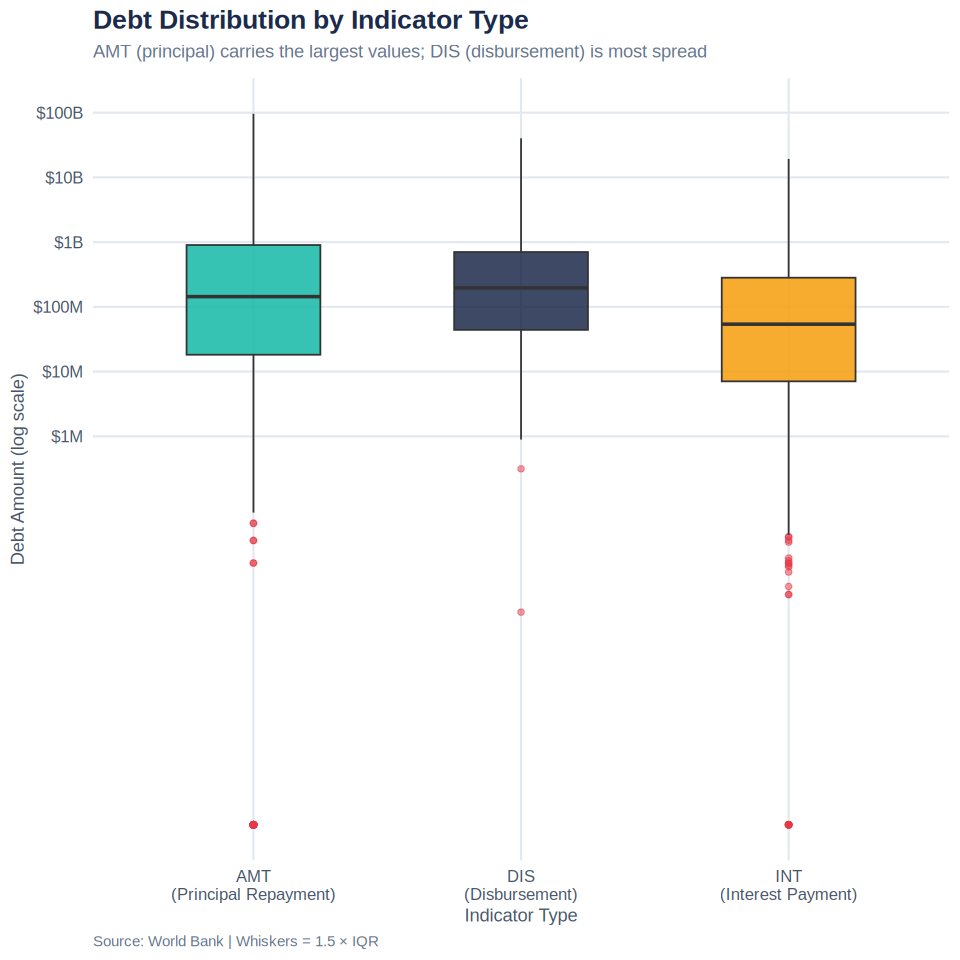

In [0]:

# -----------------------------------------------------------
# GRAPH 3: Box Plot — Debt by Indicator Type (AMT / INT / DIS)
# -----------------------------------------------------------

cat_labels <- c(AMT = "AMT\n(Principal Repayment)",
                INT = "INT\n(Interest Payment)",
                DIS = "DIS\n(Disbursement)")

p3 <- ggplot(df, aes(x = cat, y = log10(debt + 1), fill = cat)) +
  geom_boxplot(outlier.colour = PAL["red"], outlier.size = 1.5,
               outlier.alpha = 0.5, alpha = 0.85, width = 0.5) +
  scale_fill_manual(
    values = c(AMT = unname(PAL["teal"]), INT = unname(PAL["gold"]), DIS = unname(PAL["navy"])),
    labels = cat_labels
  ) +
  scale_x_discrete(labels = cat_labels) +
  scale_y_continuous(
    breaks = 6:11,
    labels = c("$1M", "$10M", "$100M", "$1B", "$10B", "$100B")
  ) +
  labs(
    title    = "Debt Distribution by Indicator Type",
    subtitle = "AMT (principal) carries the largest values; DIS (disbursement) is most spread",
    x        = "Indicator Type",
    y        = "Debt Amount (log scale)",
    caption  = "Source: World Bank | Whiskers = 1.5 \u00d7 IQR"
  ) +
  theme(legend.position = "none")

print(p3)
ggsave("graph3_boxplot_indicator_type.png", p3, width = 8, height = 6, dpi = 150)


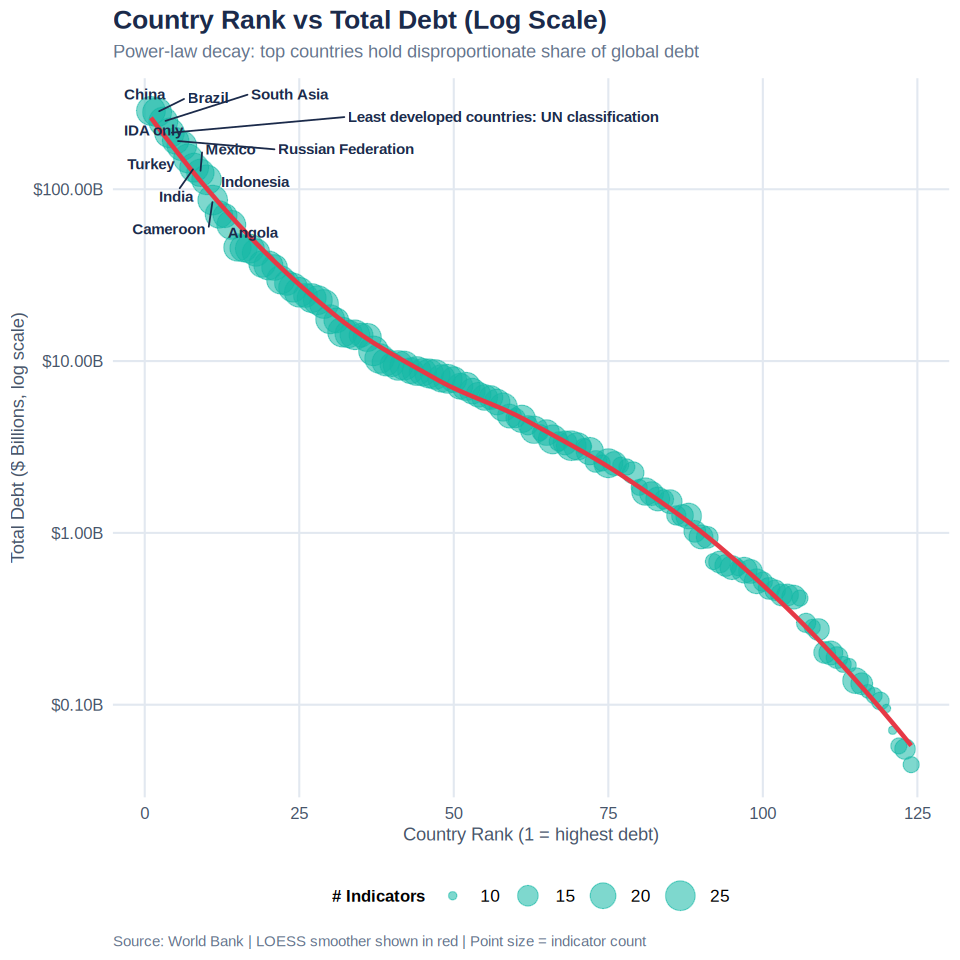

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'

In [0]:
# -----------------------------------------------------------
# GRAPH 4: Scatter + LOESS — Country Rank vs Total Debt
# -----------------------------------------------------------

country_rank_pos <- country_rank %>% filter(total_debt > 0)

p4 <- ggplot(country_rank_pos,
             aes(x = rank, y = total_debt)) +
  geom_point(aes(size = n_indicators), alpha = 0.55, colour = PAL["teal"]) +
  geom_smooth(method = "loess", colour = PAL["red"], se = FALSE,
              linewidth = 1.3, alpha = 0.9) +
  geom_text_repel(
    data        = head(country_rank_pos, 12),
    aes(label   = country_name),
    size        = 3.2,
    colour      = PAL["navy"],
    fontface    = "bold",
    max.overlaps = 20,
    box.padding = 0.4
  ) +
  scale_y_log10(labels = dollar_format(suffix = "B")) +
  scale_size_continuous(range = c(2, 8), name = "# Indicators") +
  labs(
    title    = "Country Rank vs Total Debt (Log Scale)",
    subtitle = "Power-law decay: top countries hold disproportionate share of global debt",
    x        = "Country Rank (1 = highest debt)",
    y        = "Total Debt ($ Billions, log scale)",
    caption  = "Source: World Bank | LOESS smoother shown in red | Point size = indicator count"
  )

print(p4)
ggsave("graph4_scatter_rank_debt.png", p4, width = 10, height = 6, dpi = 150)

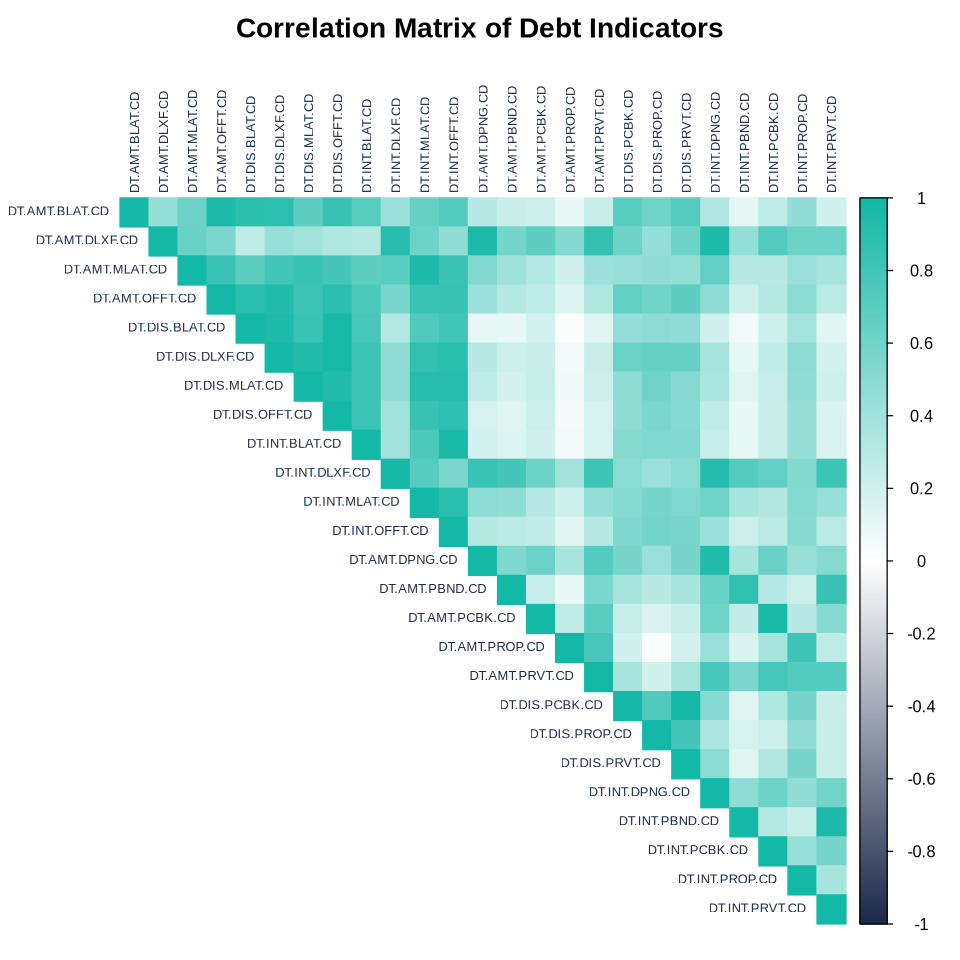

Graph 5 also saved to: graph5_correlation_heatmap.png

In [0]:

# -----------------------------------------------------------
# GRAPH 5: Correlation Heat Map of Debt Indicators
# -----------------------------------------------------------

df_wide <- df %>%
  group_by(country_name, indicator_code) %>%
  summarise(debt = mean(debt), .groups = "drop") %>%
  pivot_wider(
    names_from  = indicator_code,
    values_from = debt,
    values_fill = 0
  )

corr_matrix <- cor(df_wide[, -1], use = "pairwise.complete.obs")

corr_colors <- colorRampPalette(c(PAL["navy"], "white", PAL["teal"]))(200)

# Display inline in notebook
corrplot(
  corr_matrix,
  method     = "color",
  type       = "upper",
  tl.cex     = 0.55,
  tl.col     = PAL["navy"],
  col        = corr_colors,
  title      = "Correlation Matrix of Debt Indicators",
  mar        = c(0, 0, 2, 0),
  addCoef.col = NULL,
  cl.cex     = 0.7
)

# Also save to file
png("graph5_correlation_heatmap.png", width = 1400, height = 1200, res = 150)
corrplot(
  corr_matrix,
  method     = "color",
  type       = "upper",
  tl.cex     = 0.55,
  tl.col     = PAL["navy"],
  col        = corr_colors,
  title      = "Correlation Matrix of Debt Indicators",
  mar        = c(0, 0, 2, 0),
  addCoef.col = NULL,
  cl.cex     = 0.7
)
dev.off()
cat("Graph 5 also saved to: graph5_correlation_heatmap.png\n")

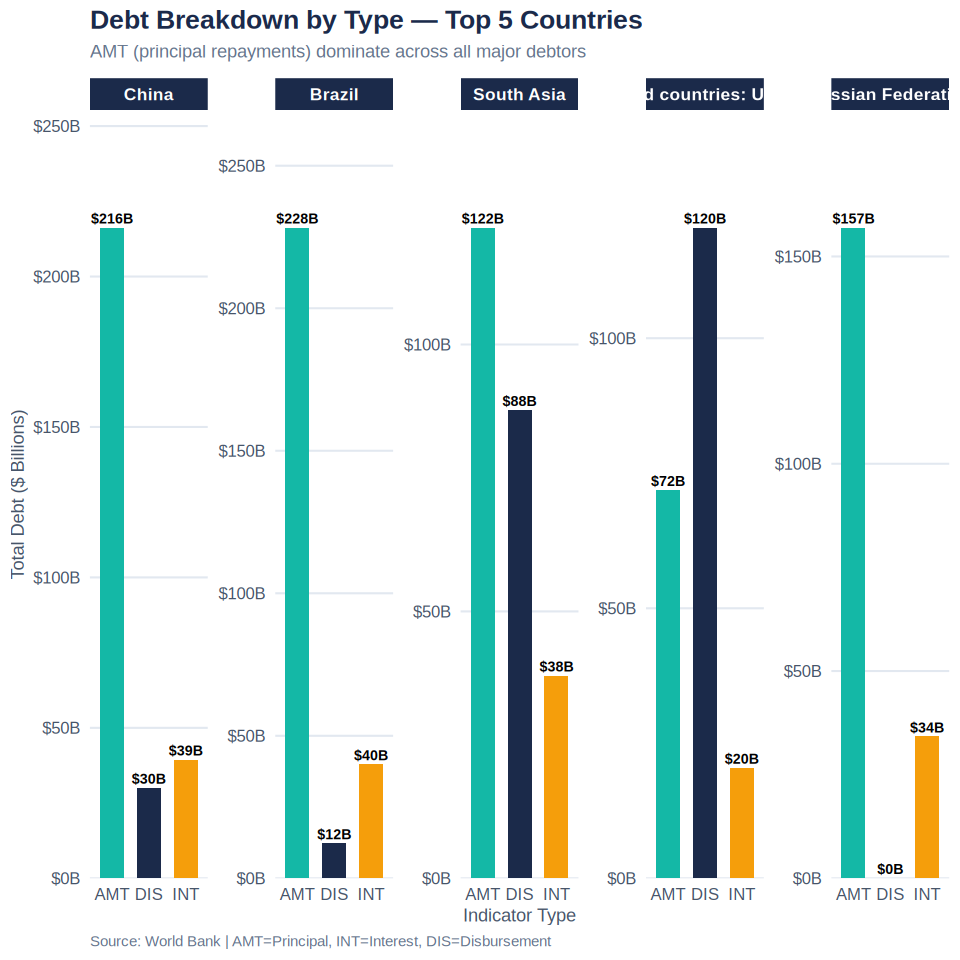

In [0]:

# -----------------------------------------------------------
# GRAPH 6: Facet Bar — Top 5 Countries Across Indicator Types
# -----------------------------------------------------------

top5_names <- country_debt$country_name[1:5]

df_facet <- df %>%
  filter(country_name %in% top5_names) %>%
  group_by(country_name, cat) %>%
  summarise(total_debt = sum(debt) / 1e9, .groups = "drop") %>%
  mutate(country_name = factor(country_name, levels = top5_names))

p6 <- ggplot(df_facet,
             aes(x = cat, y = total_debt, fill = cat)) +
  geom_col(width = 0.65, show.legend = FALSE) +
  geom_text(aes(label = paste0("$", round(total_debt, 0), "B")),
            vjust = -0.4, size = 3.0, fontface = "bold") +
  facet_wrap(~ country_name, nrow = 1, scales = "free_y") +
  scale_fill_manual(values = c(AMT = unname(PAL["teal"]),
                               INT = unname(PAL["gold"]),
                               DIS = unname(PAL["navy"]))) +
  scale_y_continuous(labels = dollar_format(suffix = "B"),
                     expand = expansion(mult = c(0, 0.18))) +
  labs(
    title    = "Debt Breakdown by Type \u2014 Top 5 Countries",
    subtitle = "AMT (principal repayments) dominate across all major debtors",
    x        = "Indicator Type",
    y        = "Total Debt ($ Billions)",
    caption  = "Source: World Bank | AMT=Principal, INT=Interest, DIS=Disbursement"
  ) +
  theme(panel.grid.major.x = element_blank(),
        strip.background    = element_rect(fill = PAL["navy"], colour = NA),
        strip.text          = element_text(colour = "white"))

print(p6)
ggsave("graph6_facet_top5_breakdown.png", p6, width = 14, height = 6, dpi = 150)


In [0]:

# ============================================================
# SECTION 5 — HYPOTHESIS TESTING
# ============================================================

cat("\n\n")
cat("============================================================\n")
cat("  HYPOTHESIS TESTING RESULTS\n")
cat("  Significance level: \u03b1 = 0.05\n")
cat("  Type I error rate:  \u03b1 = 0.05 (false positive)\n")
cat("  Type II error rate: \u03b2 = 0.20 (false negative assumed)\n")
cat("  Statistical power:  1 - \u03b2 = 0.80\n")
cat("============================================================\n\n")

interpret <- function(p, alpha = 0.05) {
  if (is.na(p)) return("    p-value is NA (test may not be applicable)")
  if (p < alpha) "*** REJECT H\u2080 (statistically significant)"
  else           "    FAIL TO REJECT H\u2080 (not significant)"
}

fmt_p <- function(p) {
  if (is.na(p)) return("NA")
  if (p < 2.2e-16) return("< 2.2e-16")
  formatC(p, format = "g", digits = 4)
}






  HYPOTHESIS TESTING RESULTS
  Significance level: α = 0.05
  Type I error rate:  α = 0.05 (false positive)
  Type II error rate: β = 0.20 (false negative assumed)
  Statistical power:  1 - β = 0.80


In [0]:
# -----------------------------------------------------------
# TEST 1: One-Sample T-Test  |  H\u2080: \u03bc = 0
# -----------------------------------------------------------
cat("\u2500\u2500 TEST 1: ONE-SAMPLE T-TEST \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\n")
cat("H\u2080: Mean debt = 0   H\u2081: Mean debt \u2260 0\n\n")

t1 <- t.test(df$debt, mu = 0, alternative = "two.sided")
print(t1)
cat(interpret(t1$p.value), "\n")
cat("Interpretation: Confirms debt values are significantly > 0 (data validity).\n\n")




── TEST 1: ONE-SAMPLE T-TEST ─────────────────────────
H₀: Mean debt = 0   H₁: Mean debt ≠ 0


	One Sample t-test

data:  df$debt
t = 12.137, df = 2356, p-value < 2.2e-16
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 1095515364 1517751066
sample estimates:
 mean of x 
1306633215 

*** REJECT H₀ (statistically significant) 
Interpretation: Confirms debt values are significantly > 0 (data validity).


In [0]:
# -----------------------------------------------------------
# TEST 2: Independent Two-Sample T-Test  |  China vs Brazil
# -----------------------------------------------------------
cat("\u2500\u2500 TEST 2: INDEPENDENT T-TEST (China vs Brazil) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\n")
cat("H\u2080: \u03bc_China = \u03bc_Brazil (per indicator)\n")
cat("H\u2081: \u03bc_China \u2260 \u03bc_Brazil\n\n")

china  <- df %>% filter(country_name == "China")  %>% pull(debt)
brazil <- df %>% filter(country_name == "Brazil") %>% pull(debt)

t2 <- t.test(china, brazil, var.equal = FALSE)
print(t2)
cat(interpret(t2$p.value), "\n")
cat("Interpretation: China & Brazil are statistically equal on a per-record basis.\n")
cat("China's larger TOTAL debt is driven by breadth of indicators, not size per record.\n\n")



── TEST 2: INDEPENDENT T-TEST (China vs Brazil) ──────────
H₀: μ_China = μ_Brazil (per indicator)
H₁: μ_China ≠ μ_Brazil


	Welch Two Sample t-test

data:  china and brazil
t = 0.033624, df = 45.602, p-value = 0.9733
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -12682445085  13113239135
sample estimates:
  mean of x   mean of y 
11908062281 11692665256 

    FAIL TO REJECT H₀ (not significant) 
Interpretation: China & Brazil are statistically equal on a per-record basis.
China's larger TOTAL debt is driven by breadth of indicators, not size per record.


In [0]:

# -----------------------------------------------------------
# TEST 3: Z-Test (Large Sample Approximation)
# -----------------------------------------------------------
cat("\u2500\u2500 TEST 3: Z-TEST (Large Sample, China vs Brazil) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\n")
cat("H\u2080: \u03bc_China = \u03bc_Brazil   H\u2081: \u03bc_China \u2260 \u03bc_Brazil\n\n")

se_pool <- sqrt(var(china) / length(china) + var(brazil) / length(brazil))
z_stat  <- (mean(china) - mean(brazil)) / se_pool
p_z     <- 2 * (1 - pnorm(abs(z_stat)))

cat("Z-statistic:", round(z_stat, 4), "\n")
cat("p-value:     ", round(p_z, 4), "\n")
cat("Critical value (\u03b1=0.05, two-tailed): \u00b11.96\n")
cat(interpret(p_z), "\n")
cat("Interpretation: Confirms T-test conclusion via large-sample normal approximation.\n")

── TEST 3: Z-TEST (Large Sample, China vs Brazil) ────────
H₀: μ_China = μ_Brazil   H₁: μ_China ≠ μ_Brazil

Z-statistic: 0.0336 
p-value:      0.9732 
Critical value (α=0.05, two-tailed): ±1.96
    FAIL TO REJECT H₀ (not significant) 
Interpretation: Confirms T-test conclusion via large-sample normal approximation.

In [0]:

# -----------------------------------------------------------
# TEST 4: One-Way ANOVA  |  Top 5 Countries
# -----------------------------------------------------------
cat("\u2500\u2500 TEST 4: ONE-WAY ANOVA (Top 5 Countries) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\n")
cat("H\u2080: All top-5 country means are equal\n")
cat("H\u2081: At least one mean differs\n\n")

df_top5  <- df %>% filter(country_name %in% top5_names)
model1   <- aov(debt ~ country_name, data = df_top5)
anova1   <- summary(model1)
print(anova1)
p_anova1 <- anova1[[1]]["country_name", "Pr(>F)"]
cat(interpret(p_anova1), "\n")
cat("Interpretation: High within-group variance \u2014 no significant between-country effect.\n\n")



── TEST 4: ONE-WAY ANOVA (Top 5 Countries) ───────────────
H₀: All top-5 country means are equal
H₁: At least one mean differs

              Df    Sum Sq   Mean Sq F value Pr(>F)
country_name   4 2.180e+20 5.449e+19   0.175  0.951
Residuals    113 3.511e+22 3.107e+20               
    FAIL TO REJECT H₀ (not significant) 
Interpretation: High within-group variance — no significant between-country effect.


In [0]:
# Post-hoc Tukey HSD
cat("\u2500\u2500 Tukey HSD Post-Hoc \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\n")
print(TukeyHSD(model1))



── Tukey HSD Post-Hoc ──────────────────────────────
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = debt ~ country_name, data = df_top5)

$country_name
                                                                       diff
China-Brazil                                                      215397025
Least developed countries: UN classification-Brazil             -3177425544
Russian Federation-Brazil                                       -2583662529
South Asia-Brazil                                               -1375635090
Least developed countries: UN classification-China              -3392822569
Russian Federation-China                                        -2799059554
South Asia-China                                                -1591032114
Russian Federation-Least developed countries: UN classification   593763015
South Asia-Least developed countries: UN classification          1801790455
South Asia-Russian Federation           

In [0]:
# ANOVA assumption checks
cat("\n\u2500\u2500 Assumption: Homogeneity of Variance (Levene's Test) \u2500\u2500\u2500\n")
print(leveneTest(debt ~ country_name, data = df_top5))

cat("\n\u2500\u2500 Assumption: Normality of Residuals (Shapiro-Wilk) \u2500\u2500\u2500\u2500\u2500\n")
resid_sample <- sample(residuals(model1), min(5000, length(residuals(model1))))
print(shapiro.test(resid_sample))
cat("Note: Shapiro-Wilk is sensitive to large n; use Q-Q plot for practical check.\n")


── Assumption: Homogeneity of Variance (Levene's Test) ───
Warning in leveneTest.default(y = y, group = group, ...) :
  group coerced to factor.
Levene's Test for Homogeneity of Variance (center = median)
       Df F value Pr(>F)
group   4  0.1711 0.9528
      113               

── Assumption: Normality of Residuals (Shapiro-Wilk) ─────

	Shapiro-Wilk normality test

data:  resid_sample
W = 0.63133, p-value = 8.833e-16

Note: Shapiro-Wilk is sensitive to large n; use Q-Q plot for practical check.

In [0]:

# -----------------------------------------------------------
# TEST 5: Two-Way ANOVA  |  Country \u00d7 Indicator Type
# -----------------------------------------------------------
cat("\u2500\u2500 TEST 5: TWO-WAY ANOVA (Country \u00d7 Indicator Type) \u2500\u2500\u2500\u2500\u2500\u2500\n")
cat("H\u2080: No main effect of country; no main effect of type; no interaction\n")
cat("H\u2081: At least one effect is significant\n\n")

model2 <- aov(log10(debt + 1) ~ country_name * cat, data = df_top5)
anova2 <- Anova(model2, type = "II")
cat("Type II Sums of Squares (from car::Anova):\n")
print(anova2)

p_country_t2 <- anova2["country_name", "Pr(>F)"]
p_cat_t2     <- anova2["cat", "Pr(>F)"]
p_interact   <- anova2["country_name:cat", "Pr(>F)"]

cat(interpret(p_country_t2), "(country)\n")
cat(interpret(p_cat_t2), "(indicator type)\n")
cat(interpret(p_interact), "(interaction)\n\n")

cat("Interpretation: After log-transformation, both country and indicator type\n")
cat("show significant main effects (Type II SS), but no interaction.\n\n")



── TEST 5: TWO-WAY ANOVA (Country × Indicator Type) ──────
H₀: No main effect of country; no main effect of type; no interaction
H₁: At least one effect is significant

Type II Sums of Squares (from car::Anova):
Anova Table (Type II tests)

Response: log10(debt + 1)
                 Sum Sq  Df F value   Pr(>F)    
country_name     20.142   4  5.4308 0.000523 ***
cat              11.107   2  5.9896 0.003461 ** 
country_name:cat  5.218   8  0.7034 0.687843    
Residuals        95.503 103                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
*** REJECT H₀ (statistically significant) (country)
*** REJECT H₀ (statistically significant) (indicator type)
    FAIL TO REJECT H₀ (not significant) (interaction)

Interpretation: After log-transformation, both country and indicator type
show significant main effects (Type II SS), but no interaction.


In [0]:
# -----------------------------------------------------------
# TEST 6: T-Test \u2014 High vs Low Indicator Groups
# -----------------------------------------------------------
cat("\u2500\u2500 TEST 6: T-TEST \u2014 HIGH vs LOW INDICATOR GROUPS \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\n")
cat("H\u2080: High-debt and low-debt indicator means are equal\n")
cat("H\u2081: They differ\n\n")

ind_means  <- df %>% group_by(indicator_code) %>% summarise(m = mean(debt))
high_codes <- ind_means %>% slice_max(m, n = 5) %>% pull(indicator_code)
low_codes  <- ind_means %>% slice_min(m, n = 5) %>% pull(indicator_code)

grp_high <- df %>% filter(indicator_code %in% high_codes) %>% pull(debt)
grp_low  <- df %>% filter(indicator_code %in% low_codes)  %>% pull(debt)

t6 <- t.test(grp_high, grp_low, var.equal = FALSE)
print(t6)
cat(interpret(t6$p.value), "\n")
cat("Interpretation: Principal repayment indicators carry significantly more debt.\n")
cat("This confirms EDA finding that AMT > INT > DIS in magnitude.\n")

── TEST 6: T-TEST — HIGH vs LOW INDICATOR GROUPS ─────────
H₀: High-debt and low-debt indicator means are equal
H₁: They differ


	Welch Two Sample t-test

data:  grp_high and grp_low
t = 7.6412, df = 547.34, p-value = 9.691e-14
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 2378425894 4024377795
sample estimates:
 mean of x  mean of y 
3334060636  132658791 

*** REJECT H₀ (statistically significant) 
Interpretation: Principal repayment indicators carry significantly more debt.
This confirms EDA finding that AMT > INT > DIS in magnitude.

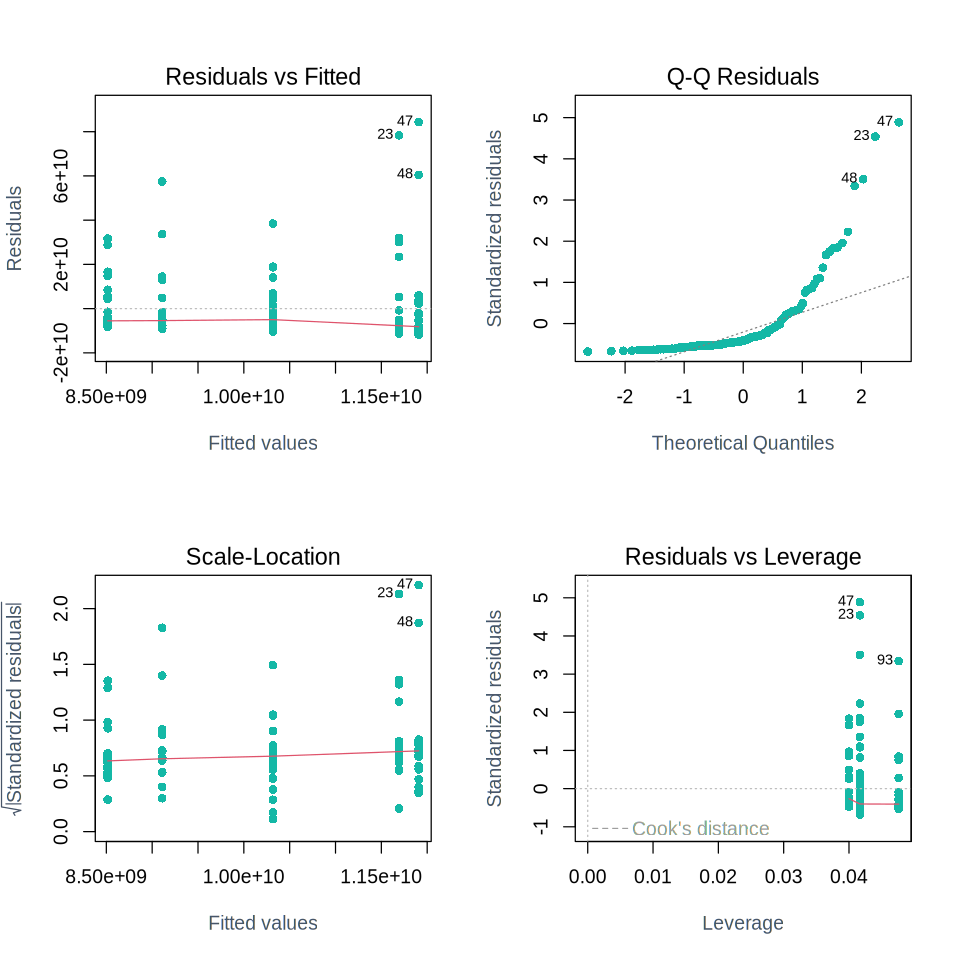

ANOVA Diagnostic Plots:
Saved: graph7_anova_diagnostics.png

In [0]:

# ============================================================
# SECTION 6 — RESIDUAL DIAGNOSTIC PLOTS (ANOVA)
# ============================================================

cat("ANOVA Diagnostic Plots:\n")
par(mfrow = c(2, 2),
    col.main = PAL["navy"],
    col.lab  = PAL["slate"])
plot(model1, col = PAL["teal"], pch = 16)

png("graph7_anova_diagnostics.png", width = 1200, height = 900, res = 150)
par(mfrow = c(2, 2),
    col.main = PAL["navy"],
    col.lab  = PAL["slate"])
plot(model1, col = PAL["teal"], pch = 16)
dev.off()
cat("Saved: graph7_anova_diagnostics.png\n")

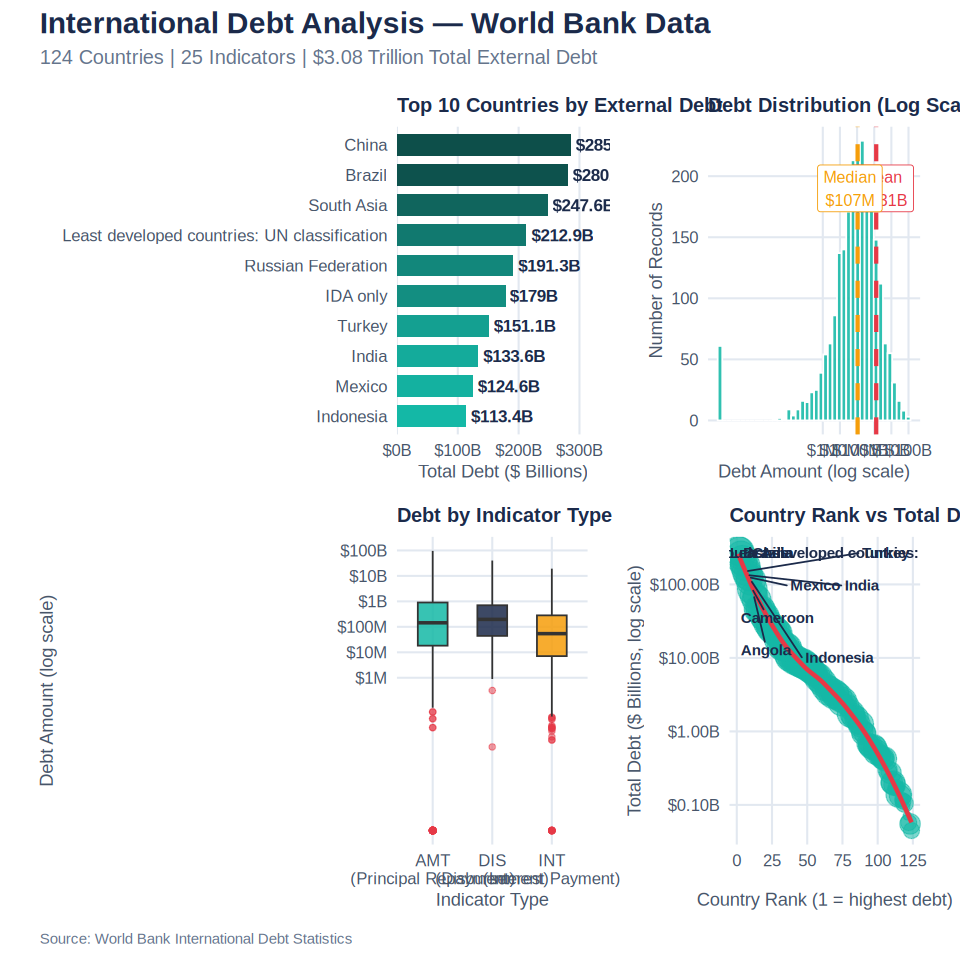

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Saved: graph8_dashboard_combined.png

In [0]:

# ============================================================
# SECTION 7 — COMBINED DASHBOARD PLOT (patchwork)
# ============================================================

# Create simplified versions of each plot for the dashboard
# (shorter titles, no subtitles/captions to prevent overlap)

d1 <- p1 + labs(title = "Top 10 Countries by External Debt",
                subtitle = NULL, caption = NULL) +
  theme(plot.title = element_text(size = 12, face = "bold"))

d2 <- p2 + labs(title = "Debt Distribution (Log Scale)",
                subtitle = NULL, caption = NULL) +
  theme(plot.title = element_text(size = 12, face = "bold"))

d3 <- p3 + labs(title = "Debt by Indicator Type",
                subtitle = NULL, caption = NULL) +
  theme(plot.title = element_text(size = 12, face = "bold"))

d4 <- p4 + labs(title = "Country Rank vs Total Debt",
                subtitle = NULL, caption = NULL) +
  theme(plot.title = element_text(size = 12, face = "bold"),
        legend.position = "none")

dashboard <- (d1 | d2) / (d3 | d4) +
  plot_layout(widths = c(1, 1), heights = c(1, 1)) +
  plot_annotation(
    title    = "International Debt Analysis \u2014 World Bank Data",
    subtitle = "124 Countries | 25 Indicators | $3.08 Trillion Total External Debt",
    caption  = "Source: World Bank International Debt Statistics",
    theme    = theme(
      plot.title    = element_text(face = "bold", size = 18, colour = PAL["navy"]),
      plot.subtitle = element_text(size = 12, colour = PAL["mid"]),
      plot.caption  = element_text(size = 9,  colour = PAL["mid"]),
      plot.margin   = margin(10, 10, 10, 10)
    )
  ) &
  theme(plot.margin = margin(8, 12, 8, 12))

print(dashboard)
ggsave("graph8_dashboard_combined.png", dashboard,
       width = 20, height = 14, dpi = 150)
cat("Saved: graph8_dashboard_combined.png\n")

In [0]:

# ============================================================
# SUMMARY OF ALL HYPOTHESIS TESTS
# ============================================================
cat("\n")
cat("==========================================================\n")
cat("  SUMMARY OF ALL HYPOTHESIS TESTS\n")
cat("  \u03b1 = 0.05 | \u03b2 = 0.20 | Power = 0.80\n")
cat("==========================================================\n\n")

decision <- function(p) {
  if (is.na(p)) return("N/A")
  ifelse(p < 0.05, "REJECT", "FAIL")
}

cat(sprintf("%-38s %-12s %-12s %s\n", "Test", "Statistic", "p-value", "Decision"))
cat(paste(rep("\u2500", 72), collapse = ""), "\n")

cat(sprintf("%-38s t = %-7.3f %-12s %s\n",
    "1. One-Sample T-Test",
    t1$statistic, fmt_p(t1$p.value), decision(t1$p.value)))

cat(sprintf("%-38s t = %-7.3f %-12s %s\n",
    "2. Welch T-Test (CHN vs BRA)",
    t2$statistic, fmt_p(t2$p.value), decision(t2$p.value)))

cat(sprintf("%-38s z = %-7.4f %-12s %s\n",
    "3. Z-Test (CHN vs BRA)",
    z_stat, fmt_p(p_z), decision(p_z)))

cat(sprintf("%-38s F = %-7.3f %-12s %s\n",
    "4. One-Way ANOVA (Top 5)",
    anova1[[1]]["country_name", "F value"], fmt_p(p_anova1),
    decision(p_anova1)))

cat(sprintf("%-38s F = %-7.3f %-12s %s\n",
    "5a. Two-Way ANOVA - Country",
    anova2["country_name", "F value"], fmt_p(p_country_t2),
    decision(p_country_t2)))

cat(sprintf("%-38s F = %-7.3f %-12s %s\n",
    "5b. Two-Way ANOVA - Type",
    anova2["cat", "F value"], fmt_p(p_cat_t2),
    decision(p_cat_t2)))

cat(sprintf("%-38s F = %-7.3f %-12s %s\n",
    "5c. Two-Way ANOVA - Interaction",
    anova2["country_name:cat", "F value"], fmt_p(p_interact),
    decision(p_interact)))

cat(sprintf("%-38s t = %-7.3f %-12s %s\n",
    "6. T-Test (High vs Low)",
    t6$statistic, fmt_p(t6$p.value), decision(t6$p.value)))

cat(paste(rep("\u2500", 72), collapse = ""), "\n")
cat("REJECT = Reject H0 | FAIL = Fail to reject H0\n")




  SUMMARY OF ALL HYPOTHESIS TESTS
  α = 0.05 | β = 0.20 | Power = 0.80

Test                                   Statistic    p-value      Decision
──────────────────────────────────────────────────────────────────────── 
1. One-Sample T-Test                   t = 12.137  < 2.2e-16    REJECT
2. Welch T-Test (CHN vs BRA)           t = 0.034   0.9733       FAIL
3. Z-Test (CHN vs BRA)                 z = 0.0336  0.9732       FAIL
4. One-Way ANOVA (Top 5)               F = 0.175   0.9506       FAIL
5a. Two-Way ANOVA - Country            F = 5.431   0.000523     REJECT
5b. Two-Way ANOVA - Type               F = 5.990   0.003461     REJECT
5c. Two-Way ANOVA - Interaction        F = 0.703   0.6878       FAIL
6. T-Test (High vs Low)                t = 7.641   9.691e-14    REJECT
──────────────────────────────────────────────────────────────────────── 
REJECT = Reject H0 | FAIL = Fail to reject H0

In [0]:
cat("\nKey Findings:\n")
cat("  \u2022 Test 1: Debt > 0 confirmed (data valid)\n")
cat("  \u2022 Tests 2-3: China \u2248 Brazil per indicator\n")
cat("  \u2022 Test 4: No difference among top-5 (raw)\n")
cat("  \u2022 Test 5: Country & type significant (log)\n")
cat("  \u2022 Test 6: High indicators \u224825x > low ones\n")

cat("\n==========================================================\n")
cat("  ANALYSIS COMPLETE \u2014 All graphs and tests generated.\n")
cat("==========================================================\n")


Key Findings:
  • Test 1: Debt > 0 confirmed (data valid)
  • Tests 2-3: China ≈ Brazil per indicator
  • Test 4: No difference among top-5 (raw)
  • Test 5: Country & type significant (log)
  • Test 6: High indicators ≈25x > low ones

  ANALYSIS COMPLETE — All graphs and tests generated.